# Mount to drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


# Build Sol Dataset

## Install necessary libraries from python

In [ ]:
# Use Gpu
!pip install dgl==2.0.0 -f https://data.dgl.ai/wheels/cu121/repo.html
# Only use cpu
# !pip install dgl==1.1.2

Looking in links: https://data.dgl.ai/wheels/cu121/repo.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.0/926.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 33.7 MB/s eta 0:00:00


In [ ]:
%%capture
# !apt install libgraphviz-dev
# !pip install pygraphviz
!pip install networkx
!pip install slither-analyzer

## Import Python libraries

In [ ]:
from concurrent.futures import ThreadPoolExecutor
from random import sample
import json
import multiprocessing
import traceback
import pandas as pd
import os
from pathlib import Path
import networkx as nx
# import pygraphviz as pgv
import matplotlib.pyplot as plt
import nltk
import dgl
import os
import shutil
import random
from slither.slither import Slither
from typing import Tuple, Optional, Dict
from copy import deepcopy
from pathlib import Path
import glob
from multiprocessing import Pool as ThreadPool
from functools import partial
import torch.nn as nn
import torch
from torch import Tensor
import torch.nn.functional as F
from dgl.nn import GraphConv, GATConv, TAGConv, SAGEConv, GINConv, SumPooling, AvgPooling, MaxPooling, SortPooling, GlobalAttentionPooling, WeightAndSum, Set2Set, SetTransformerEncoder, SetTransformerDecoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pickle
import random
import numpy as np
from tqdm import tqdm
from gensim.models import Word2Vec

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


## Functions

In [ ]:
def deleteSolDataset(link):
  # for sol_type in os.listdir(link):
    sol_type = "Scam"
    dir = os.listdir(f"{link}/{sol_type}")
    for sol in dir:
      if sol.endswith('.sol') and 'buggy' in sol:
        os.remove(f"{link}/{sol_type}/{sol}")

# deleteSolDataset(link="/content/drive/MyDrive/ScamSolidityCodeDetection/SolDataset")

In [ ]:
def buildSolDataset(link):
  try:
    for sol_type in os.listdir(link):
      dt_list = []
      for folder in ['train', 'validation', 'test']:
        for parquet in os.listdir(f"{link}/{sol_type}/{folder}"):
          if parquet.endswith('.parquet'):
            tmp = pd.read_parquet(f"{link}/{sol_type}/{folder}/{parquet}")
            dt_list.append(tmp)

      df = pd.concat(dt_list, axis=0)
      df = df.reset_index(drop=True)
      src_dict = df['contract_address'].value_counts().to_dict()
      n_files = []
      for src in df['contract_address']:
        n_files.append(src_dict[src])

      df = pd.concat([df, pd.Series(n_files, name='file_count')], axis=1)

      # Sort out rows with source_code do not contain imports and only have 1 sol file for the contract
      noi_df = df[~df['source_code'].str.contains('import')]
      noi_df = noi_df[noi_df['file_count'] == 1]
      noi_df = noi_df.reset_index(drop=True)

      # for i in range(len(noi_df)):
      #   tmp = noi_df.loc[i]
      #   #Write new sol dataseyt for each type
      #   with open(f"{link}/{sol_type}/{tmp['contract_address']}.sol", "w") as file:
      #     file.write(tmp['source_code'])
      return noi_df

  except Exception as e:
      print(f"Error in delete({link}): {e}")
      traceback.print_exc()

def getSolDataset(link):
    sol_type = "NonScam_parquet"
    dt_list = []
    for folder in ['train', 'validation', 'test']:
      for parquet in os.listdir(f"{link}/{sol_type}/{folder}"):
        if parquet.endswith('.parquet'):
          tmp = pd.read_parquet(f"{link}/{sol_type}/{folder}/{parquet}")
          dt_list.append(tmp)

    df = pd.concat(dt_list, axis=0)
    df = df.reset_index(drop=True)
    src_dict = df['contract_address'].value_counts().to_dict()
    n_files = []
    for src in df['contract_address']:
      n_files.append(src_dict[src])

    df = pd.concat([df, pd.Series(n_files, name='file_count')], axis=1)

    # Sort out rows with source_code do not contain imports and only have 1 sol file for the contract
    noi_df = df[~df['source_code'].str.contains('import')]
    noi_df = noi_df[noi_df['file_count'] == 1]
    noi_df = noi_df.reset_index(drop=True)

    # for i in range(len(noi_df)):
    #   tmp = noi_df.loc[i]
    #   #Write new sol dataseyt for each type
    #   with open(f"{link}/{sol_type}/{tmp['contract_address']}.sol", "w") as file:
    #     file.write(tmp['source_code'])
    return noi_df

# buildSolDataset(link="/content/drive/MyDrive/ScamSolidityCodeDetection/SolDataset")
# df = getSolDataset(link="/content/drive/MyDrive/ScamSolidityCodeDetection/SolDataset")

In [ ]:
# flist = df['contract_address'].tolist()
# flist = flist[:70000]

# def deleteSolFile(link, nfile):
#   try:
#       os.remove(f"{link}/{nfile}.sol")
#       print("Deleted file:", f"{link}/{nfile}.sol")
#   except Exception as e:
#     print('Error delete file:', str(e))

# for nfile in flist:
#   deleteSolFile(link="/content/drive/MyDrive/ScamSolidityCodeDetection/SolDataset/NonScam", nfile=nfile)

In [ ]:
def checkFolerSize(link: Path):
  return len(os.listdir(link))

def cntSolFiles(link: Path):
  return len([f for f in os.listdir(link) if f.endswith('.sol')])

# print(checkFolerSize("/content/drive/MyDrive/ScamSolidityCodeDetection/SolDataset/NonScam"))

In [ ]:
def copy_random_files(source_folder, destination_folder, num_files):
    # Get a list of all Solidity files in the source folder
    all_files = [f for f in os.listdir(source_folder) if f.endswith('.sol')]

    # Choose a random subset of 3000 files
    random_subset = random.sample(all_files, min(num_files, len(all_files)))

    # Ensure the destination folder exists
    os.makedirs(destination_folder, exist_ok=True)

    # Copy selected files to the destination folder
    for file_name in random_subset:
        source_path = os.path.join(source_folder, file_name)
        destination_path = os.path.join(destination_folder, file_name)
        shutil.copy2(source_path, destination_path)

    print(f"Successfully copied {len(random_subset)} files to {destination_folder}")

# # Example usage
# source_folder = '/content/drive/MyDrive/ScamSolidityCodeDetection/SolDataset/NonScam'
# destination_folder = '/content/drive/MyDrive/ScamSolidityCodeDetection/SolDataset/NonScam2'
# num_files_to_copy = 3000

# copy_random_files(source_folder, destination_folder, num_files_to_copy)

In [ ]:
def copy_files(source_folder, destination_folder, ftype, activ=False):
    if activ == True:
        # Get a list of all Solidity files in the source folder
        all_files = [f for f in os.listdir(f"{source_folder}") if f.endswith('.sol')]

        # Ensure the destination folder exists
        os.makedirs(destination_folder, exist_ok=True)

        # Copy selected files to the destination folder
        for file_name in all_files:
            source_path = os.path.join(f"{source_folder}", file_name)
            destination_path = os.path.join(destination_folder, f"{ftype}_{file_name}")
            shutil.copy2(source_path, destination_path)

        print(f"Successfully copied {len(all_files)} files to {destination_folder}")
    else:
      print("Function active is off!")

# Example usage
source_folder = '/content/ge-sc/data/solidifi_buggy_contracts'
destination_folder = '/content/drive/MyDrive/ScamSolidityCodeDetection/SolDataset/Scam'

ftypes = [
    'unchecked_low_level_calls', 'denial_of_service',
    'access_control', 'front_running', 'arithmetic',
    'time_manipulation', 'reentrancy'
    ]

# for ftype in ftypes:
#   copy_files(f"{source_folder}/{ftype}", destination_folder, ftype, True)

# Functions

In [ ]:
def plot(x: list, y: list):
  x = np.array(x)
  y = np.array(y)

  plt.plot(x, y)
  plt.title("Decrease of loss over epochs")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.show()

In [ ]:
def readData(path: str, n_nscam: int, n_scam: int, error: str):
  dic = {
      "filename": [],
      "label": []
  }
  cnt0, cnt1 = 0, 0
  for label in [f"Non{error}", error]:
    for file in sorted(os.listdir(path + "/" + label)):
      if file.endswith(".fcg"):
        if label == f"Non{error}":
          if cnt0 <= n_nscam:
            dic['filename'].append("/".join([path, label, file]))
            dic['label'].append(0)
            cnt0 += 1
        else:
          if cnt1 <= n_scam:
            dic['filename'].append("/".join([path, label, file]))
            dic['label'].append(1)
            cnt1 += 1
  df = pd.DataFrame(dic)
  return df

In [ ]:
def loadfeatureGraph_5(path):
  """
    path: path to fcg file

    return: dgl.DGLGraph with feature size of 5
  """
  g = dgl.load_graphs(path)[0][0]
  return g

def loadfeatureGraph_100(path):
  """
    path: path to fcg file

    return: dgl.DGLGraph with feature size of 100
  """
  g = dgl.load_graphs(path)[0][0]
  g.ndata["features"] = g.ndata["featuresH"]
  return g

def loadfeatureGraph_105(path):
  """
    path: path to fcg file

    return: dgl.DGLGraph with feature size of 105
  """
  g = dgl.load_graphs(path)[0][0]
  template = g.ndata["features"]

  g.ndata["features"] = torch.cat([g.ndata["featuresH"], template], dim=1)
  return g

def createBatchMulThread_MultiOp(data, max_works, nfeatures):
  """
    data: Graph paths,
    nfeatures: Size of node feature
    max_works: number of thread use

    return list[DGLGraph]
  """
  pathfiles = data
  if nfeatures == 5:
    with ThreadPoolExecutor(max_works) as executor:
      graphs = list(executor.map(loadfeatureGraph_5, pathfiles))
  elif nfeatures == 768:
    with ThreadPoolExecutor(max_works) as executor:
      graphs = list(executor.map(loadfeatureGraph_100, pathfiles))
  elif nfeatures == 773:
    with ThreadPoolExecutor(max_works) as executor:
      graphs = list(executor.map(loadfeatureGraph_105, pathfiles))
  return graphs

# Model GNNs

In [ ]:
import dgl.nn.pytorch as dglnn
import torch.nn as nn
from copy import deepcopy as dc

def get_convolution_layer(
            input_dimension: int,
            output_dimension: int,
            name: list,
            agg_hidden_dimension: int = 1024, # Only use for GINConv
            heads: int = 0 # Only use for GATConv
    ) -> Optional[nn.Module]:
        mlp, gin_agg, sage_agg = None, 'sum', 'mean'
        if name[0] == "GIN":
          mlp = nn.Sequential()
          mlp.append(nn.Linear(input_dimension, agg_hidden_dimension))
          mlp.append(nn.ReLU())
          mlp.append(nn.Linear(agg_hidden_dimension, output_dimension))
          gin_agg = name[1]

        if name[0] == "SAGE":
          sage_agg = name[1]

        return {"GCN": GraphConv(input_dimension, output_dimension, activation=F.relu),
                "SAGE": SAGEConv(input_dimension, output_dimension, activation=F.relu, norm=F.normalize, aggregator_type=sage_agg),
                "GAT": GATConv(input_dimension, output_dimension, num_heads=heads, activation=F.relu, feat_drop=0.0, attn_drop=0.0),
                "TAG": TAGConv(input_dimension, output_dimension, k=4, activation=F.relu),
                "GIN": GINConv(apply_func=mlp, activation=F.relu, aggregator_type=gin_agg)
                }.get(name[0], None)

def get_pooling_method(
            method_name: str
    ):
        return {"max": MaxPooling(),
                "mean": AvgPooling(),
                "sum": SumPooling(),
                "sort": SortPooling(k=3), # It first sorts the node features in ascending order along the feature dimension, and selects the sorted features of top-k nodes (ranked by the largest value of each node).
                "transformer": (SetTransformerEncoder(5, 4, 4, 20), SetTransformerDecoder(5, 4, 4, 20, 1, 3))}.get(method_name, None)

class GraphNN(nn.Module):
    def __init__(self, mtype, infeats, hfeats: list, fc1_layer, fc2_layer, outclass, gptype='max', ginfeat=None):
        super(GraphNN, self).__init__()
        self.mtype = mtype
        self.gptype = gptype
        self.hfeats = hfeats
        self.device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

        if mtype[0] == "GIN":
          self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0],
                                             name=mtype, agg_hidden_dimension=ginfeat)
          if len(hfeats) >= 2:
            self.conv2 = get_convolution_layer(input_dimension=hfeats[0], output_dimension=hfeats[1],
                                               name=mtype, agg_hidden_dimension=ginfeat)
          if len(hfeats) >= 3:
            self.conv3 = get_convolution_layer(input_dimension=hfeats[1], output_dimension=hfeats[2],
                                               name=mtype, agg_hidden_dimension=ginfeat)
        else:
          if mtype != ["GAT"]:
            self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0], name=mtype)
            if len(hfeats) >= 2:
                self.conv2 = get_convolution_layer(input_dimension=hfeats[0], output_dimension=hfeats[1], name=mtype)
            if len(hfeats) >= 3:
                self.conv3 = get_convolution_layer(input_dimension=hfeats[1], output_dimension=hfeats[2], name=mtype)
          else:
            if len(hfeats) > 1:
              self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0], name=mtype, heads=8)
            elif len(hfeats) == 1:
              self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0], name=mtype, heads=1)
            if len(hfeats) > 2:
              self.conv2 = get_convolution_layer(input_dimension=(hfeats[0] * 8), output_dimension=(hfeats[1] * 8), name=mtype, heads=8)
            elif len(hfeats) == 2:
              self.conv2 = get_convolution_layer(input_dimension=(hfeats[0] * 8), output_dimension=hfeats[1], name=mtype, heads=1)
            if len(hfeats) == 3:
              self.conv3 = get_convolution_layer(input_dimension=(hfeats[1] * 8), output_dimension=hfeats[2], name=mtype, heads=1)


        self.fc1 = nn.Linear(hfeats[-1], fc1_layer)
        self.fc2 = nn.Linear(fc1_layer, fc2_layer)
        self.fc3 = nn.Linear(fc2_layer, outclass)

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)

    def forward(self, g, infeats):
        # Apply graph convolution and activation.
        h = self.conv1(g, infeats)
        if self.mtype == ["GAT"]: h = h.reshape(h.shape[0], -1)
        if len(self.hfeats) >= 2:
          h = self.conv2(g, h)
          if self.mtype == ["GAT"]: h = h.reshape(h.shape[0], -1)
        if len(self.hfeats) >= 3:
          h = self.conv3(g, h)
          if self.mtype == ["GAT"]: h = h.reshape(h.shape[0], -1)
        # with g.local_scope():
        g.ndata['features'] = h
        if self.gptype == "transformer":
          enc_nodes, dec_nodes = get_pooling_method(self.gptype)
          h = enc_nodes(g, g.ndata['features'])
          h = dec_nodes(g, g.ndata['features'])
        else:
          pooling_nodes = get_pooling_method(self.gptype)
          h = pooling_nodes(g, g.ndata['features'])
        ans = self.fc1(h)
        ans = F.relu(ans)
        ans = self.fc2(ans)
        ans = F.relu(ans)
        return self.fc3(ans)

    def save(self, path):
      torch.save(self.state_dict(), path)

    def load(self, path):
      self.load_state_dict(torch.load(path))

# Training

In [ ]:
from dgl.data import DGLDataset
from dgl.dataloading import GraphDataLoader

class GraphDataset(DGLDataset):
    def __init__(self, graphs, labels):
        super().__init__(name='graph_dataset')
        self.graphs = graphs
        self.labels = labels
    def process(self):
        # Here, you could preprocess the data if needed.
        pass

    def __getitem__(self, idx):
        return self.graphs[idx], self.labels[idx]

    def __len__(self):
        return len(self.graphs)

In [ ]:
def train_and_eval(dataloader, tdataloader, mtype, s_epoch, e_epoch, n_workers, n_feats, hfeats, gptype, ginfeat):
    model = GraphNN(mtype=mtype, infeats=n_feats, hfeats=hfeats, fc1_layer=256, fc2_layer=64, outclass=2, gptype=gptype, ginfeat=ginfeat)
    model.to(model.device)
    print(model)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = torch.nn.CrossEntropyLoss()

    result = {
        "data": os.path.basename(data_path),
        "loss":[],
        "val_acc": [],
        "val_f1": [],
        "epoch": []
    }

    for epoch in (range(s_epoch, e_epoch)):
        bloss, bpred, blabel = [], [], []
        for batched_graph, label_batch in tqdm(dataloader):
            batched_graph, label_batch = batched_graph.to(model.device), label_batch.to(model.device)
            feats = batched_graph.ndata['features']
            model.train()
            pred_batch = model(batched_graph, feats)
            loss = criterion(pred_batch, label_batch)
            out_batch = pred_batch.argmax(dim=1).long()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            bloss.append(loss.item())
            bpred.extend(out_batch.tolist())
            blabel.extend(label_batch.tolist())


        result['loss'].append(sum(bloss)/len(bloss))
        result['epoch'].append(epoch)
        print("Epoch:", epoch, "   Loss:", sum(bloss)/len(bloss),f"   Accuracy: {(accuracy_score(bpred, blabel)* 100):.4f}%")
        # if os.path.exists(f"/content/drive/MyDrive/ScamSolidityCodeDetection/ModelWeights/{mtype[0]}_{mtype[1]}_{len(hfeats)}_{gptype}_f{n_feats}") == False:
        #     os.mkdir(f"/content/drive/MyDrive/ScamSolidityCodeDetection/ModelWeights/{mtype[0]}_{mtype[1]}_{len(hfeats)}_{gptype}_f{n_feats}")
        # model.save(f"/content/drive/MyDrive/ScamSolidityCodeDetection/ModelWeights/{mtype[0]}_{mtype[1]}_{len(hfeats)}_{gptype}_f{n_feats}/model_{os.path.basename(data_path)}_{str(epoch).zfill(2)}.pt")
        model.eval()
        with torch.no_grad():
            tpred, tlabel = [], []
            for tbatched_graph, tlabels in (tdataloader):
                tbatched_graph, tlabels = tbatched_graph.to(model.device), tlabels.to(model.device)
                tfeats = tbatched_graph.ndata['features']
                out = model(tbatched_graph, tfeats)
                preds = out.argmax(dim=1).long()
                tpred.extend(preds.tolist())
                tlabel.extend(tlabels.tolist())

            print(f'Val Accuracy: {(accuracy_score(tlabel, tpred) * 100):.2f}%')
            print(f'Val F1 Score: {(f1_score(np.array(tlabel), np.array(tpred)) * 100):.2f}%')
            print(f'Val Precision: {(precision_score(tlabel, tpred) * 100):.2f}%')
            print(f'Val Recall: {(recall_score(tlabel, tpred) * 100):.2f}%')
            result['val_acc'].append(accuracy_score(tlabel, tpred))
            result['val_f1'].append(f1_score(np.array(tlabel), np.array(tpred)))

    plot(result["epoch"], result["loss"])
    return result

In [ ]:
data_path = "/content/drive/MyDrive/ScamSolidityCodeDetection/FcgDataset/TimestampDependencyFcgDataset"

df = readData(data_path, 2047, 2047, 'TimestampDependency')
display(df.head())
print(f"Dataset size: {len(df)} files")

X_train, X_test, y_train, y_test = train_test_split(df.drop(['label'], axis=1), df['label'], test_size=0.2, random_state=42)

graphs = createBatchMulThread_MultiOp(X_train['filename'].tolist(), 16, 773)
graphs = [dgl.add_self_loop(g) for g in graphs]
dataset = GraphDataset(graphs, Tensor(list(y_train)).long())
dataloader = GraphDataLoader(
    dataset,
    batch_size=128,
    drop_last=False,
    shuffle=True)

tgraphs = createBatchMulThread_MultiOp(X_test['filename'].tolist(), 16, 773)
tgraphs = [dgl.add_self_loop(g) for g in tgraphs]
tdataset = GraphDataset(tgraphs, Tensor(list(y_test)).long())
tdataloader = GraphDataLoader(
    tdataset,
    batch_size=512,
    drop_last=False,
    shuffle=True)

,filename,label
0,/content/drive/MyDrive/ScamSolidityCodeDetecti...,0
1,/content/drive/MyDrive/ScamSolidityCodeDetecti...,0
2,/content/drive/MyDrive/ScamSolidityCodeDetecti...,0
3,/content/drive/MyDrive/ScamSolidityCodeDetecti...,0
4,/content/drive/MyDrive/ScamSolidityCodeDetecti...,0


Dataset size: 4095 files


In [ ]:
print(len(df[df['label'] == 0]), len(df[df['label'] == 1]))

1765 1765


In [ ]:
import os

print(len(os.listdir("/content/drive/MyDrive/ScamSolidityCodeDetection/FcgDataset/UnhandledExceptionsFcgDataset/NonUnhandledExceptions")))
print(len(os.listdir("/content/drive/MyDrive/ScamSolidityCodeDetection/FcgDataset/UnhandledExceptionsFcgDataset/UnhandledExceptions")))
print(len(os.listdir("/content/drive/MyDrive/ScamSolidityCodeDetection/FcgDataset/TimestampDependencyFcgDataset/NonTimestampDependency")))
print(len(os.listdir("/content/drive/MyDrive/ScamSolidityCodeDetection/FcgDataset/TimestampDependencyFcgDataset/TimestampDependency")))
print(len(os.listdir("/content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/UnhandledExceptions")))
print(len(os.listdir("/content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/TimestampDependency")))

0
2252
2034
2047
3640
2139


GraphNN(
  (conv1): GATConv(
    (fc): Linear(in_features=773, out_features=8192, bias=False)
    (feat_drop): Dropout(p=0.0, inplace=False)
    (attn_drop): Dropout(p=0.0, inplace=False)
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (conv2): GATConv(
    (fc): Linear(in_features=8192, out_features=512, bias=False)
    (feat_drop): Dropout(p=0.0, inplace=False)
    (attn_drop): Dropout(p=0.0, inplace=False)
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)


100%|██████████| 26/26 [00:03<00:00,  7.96it/s]


Epoch: 0    Loss: 0.6701381917183216    Accuracy: 80.2198%
Val Accuracy: 88.64%
Val F1 Score: 87.24%
Val Precision: 92.17%
Val Recall: 82.81%


100%|██████████| 26/26 [00:03<00:00,  8.10it/s]


Epoch: 1    Loss: 0.25346919607657653    Accuracy: 91.1172%
Val Accuracy: 92.19%
Val F1 Score: 91.96%
Val Precision: 88.83%
Val Recall: 95.31%


...

Epoch: 47    Loss: 0.007937241912049312    Accuracy: 99.7253%
Val Accuracy: 94.87%
Val F1 Score: 94.57%
Val Precision: 93.85%
Val Recall: 95.31%


100%|██████████| 26/26 [00:03<00:00,  7.88it/s]


Epoch: 48    Loss: 0.006886530764929306    Accuracy: 99.7863%
Val Accuracy: 95.85%
Val F1 Score: 95.65%
Val Precision: 93.97%
Val Recall: 97.40%


100%|██████████| 26/26 [00:03<00:00,  7.92it/s]


Epoch: 49    Loss: 0.008339919594268745    Accuracy: 99.7558%
Val Accuracy: 95.60%
Val F1 Score: 95.40%
Val Precision: 93.72%
Val Recall: 97.14%


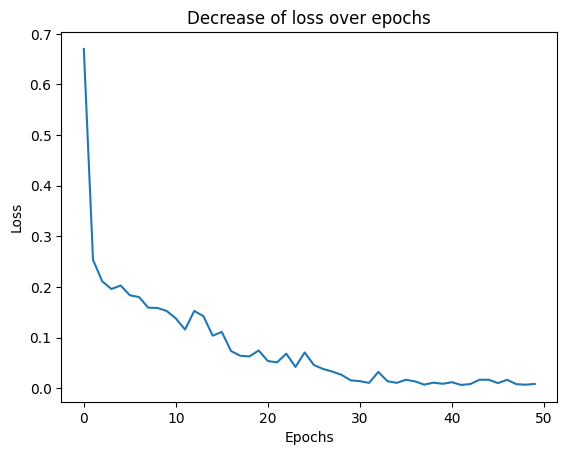

In [ ]:
# GCN, SAGE, GAT, TAG, GIN
# layer 1, 2, 3
# 128
# 256, 128
# 256, 256, 128

n_feats = 773
n_batch=128

# result_dict = {}
# for mtype in [['GAT'], ['SAGE', 'pool'], ['SAGE', 'mean'], ['SAGE', 'lstm'], ['GCN'], ['TAG'], ['GIN', 'max'], ['GIN', 'sum'], ['GIN', 'mean']]:
#     for hfeats in [[128], [256, 128], [256, 256, 128]]:
#         for gptype in ['sum', 'mean', 'max']:
#             print(mtype, hfeats, gptype)
#             tmp = train_and_eval(dataloader=dataloader, tdataloader=tdataloader, mtype=mtype,
#                                         s_epoch=0, e_epoch=500, n_workers=64, n_feats=n_feats,
#                                         hfeats=hfeats, gptype=gptype, ginfeat=1024)
#             res = [(i, j) for i, j in zip(tmp['val_f1'], tmp['val_acc'])]
#             print(max(res))
#             result_dict[f"{mtype}_{hfeats}_{gptype}"] = tmp

result = train_and_eval(dataloader=dataloader, tdataloader=tdataloader, mtype=['GAT'],
                                        s_epoch=0, e_epoch=50, n_workers=64, n_feats=n_feats,
                                        hfeats=[1024, 512], gptype='max', ginfeat=1024)

In [ ]:
res = [(i, j) for i, j in zip(result['val_f1'], result['val_acc'])]
print(max(res))

(0.9565217391304348, 0.9584859584859585)


In [ ]:
import json

line_list = [EFcgDataset]
name_list = ['EFcgDataset']

for i in range(len(line_list)):
  with open(f"/content/drive/MyDrive/ScamSolidityCodeDetection/plots/{name_list[i]}_{mtype}_{len(hfeats)}.json", "w") as outfile:
      json.dump(line_list[i], outfile)

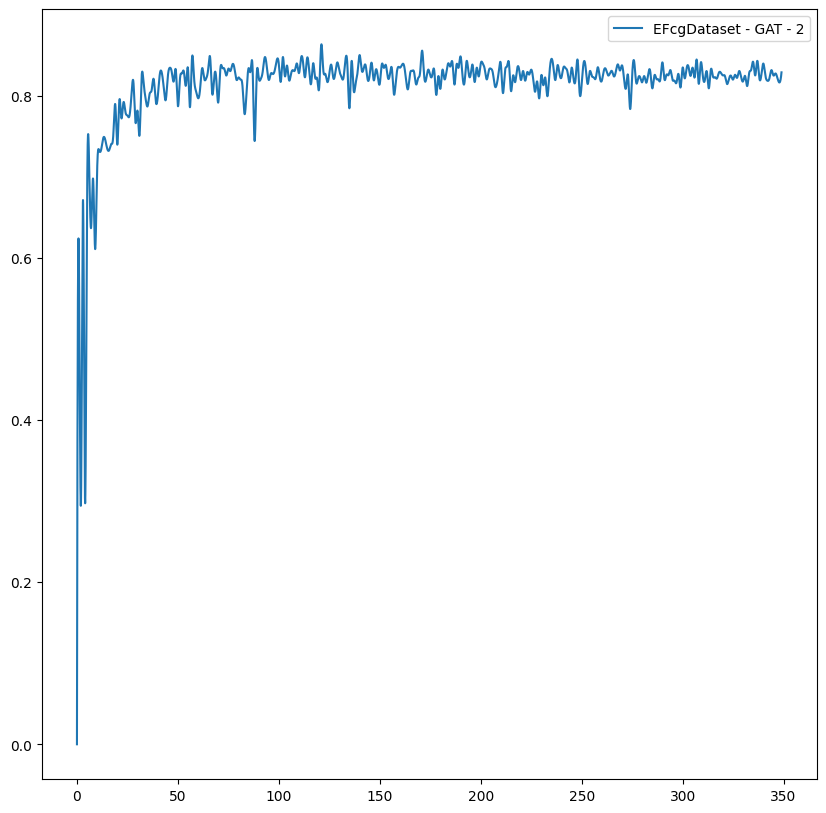

In [ ]:
# importing package
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

def ploting(line_list, name_list, line_type):
  epoches = range(350)
  plt.figure(figsize=(10, 10))
  for i in range(len(line_list)):
    # plot lines
    X_Y_Spline = make_interp_spline(epoches, line_list[i][line_type])
    X_ = np.linspace(min(epoches), max(epoches), 50000)
    Y_ = X_Y_Spline(X_)

    plt.plot(X_, Y_, label = name_list[i])
  plt.legend()
  plt.show()

ploting([EFcgDataset], ['EFcgDataset - GAT - 2'], 'val_f1')

In [ ]:
# (0.852112676056338, 0.8775510204081632)
res = [(i, j) for i, j in zip(EFcgDataset['val_f1'], EFcgDataset['val_acc'])]

print(max(res))

(0.8581560283687943, 0.8833819241982507)


# Checking

In [ ]:
!mkdir  /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam
!mkdir  /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam

In [ ]:
# !zip -r /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam/EFcgDataset_NonScam.zip /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/NonScam
!zip -r /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam/EFcgDataset_Scam.zip /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/Scam

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  adding: content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/Scam/0x34769d3e122c93547836addd3eb298035d68f1c3.fcg (deflated 20%)
  adding: content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/Scam/0x8ac32feab3d07ae0b323f2b8a077d553e4a29339.fcg (deflated 28%)
  adding: content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/Scam/0xdAd298d2A9D7DF0AD2Ac74203658A467a30861E6.fcg (deflated 20%)
  adding: content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/Scam/0x4212994013e3ECe686b8219BA61C61f297010b04.fcg (deflated 22%)
  adding: content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/Scam/0xd3dfd70bc014d86a397e3bb0c50488dc22cdc1fd.fcg (deflated 21%)
  adding: content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/Scam/0xc464d2b006bc85591F6bbc6D17e9F0f975E77bd3.fcg (deflated 18%)
  adding: content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/Scam/0x8E7587C9678F56dEE1270cFA31761789BB762566.fcg

In [ ]:
import os
import json
# quangnguyen11037 benign (1 - 13)
# quangnguyen2910 benign (14 - 25)
# quangnm711 malware (full)

dictionary = {
  "title": f"Sol_Dataset_EFcg_NonScam",
  "id": f"quangnguyen11037/sol-dataset-efcg-nonscam",
  "licenses": [
    {
      "name": "CC0-1.0"
    }
  ]
}

# Serializing json
json_object = json.dumps(dictionary, indent=2)

# Writing to sample.json
with open(f"/content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam/dataset-metadata.json", "w") as outfile:
    outfile.write(json_object)

dictionary = {
  "title": f"Sol_Dataset_EFcg_Scam",
  "id": f"quangnguyen11037/sol-dataset-efcg-scam",
  "licenses": [
    {
      "name": "CC0-1.0"
    }
  ]
}

# Serializing json
json_object = json.dumps(dictionary, indent=2)

# Writing to sample.json
with open(f"/content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam/dataset-metadata.json", "w") as outfile:
    outfile.write(json_object)

In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = "/content/quangnguyen11037"

In [ ]:
!chmod 600 /content/quangnguyen11037/kaggle.json

In [ ]:
!kaggle datasets create -p /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam --dir-mode skip --public
!kaggle datasets create -p /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam --dir-mode skip --public

Starting upload for file EFcgDataset_NonScam.zip
100% 233M/233M [00:03<00:00, 63.6MB/s]
Upload successful: EFcgDataset_NonScam.zip (233MB)
Your public Dataset is being created. Please check progress at https://www.kaggle.com/datasets/quangnguyen11037/sol-dataset-efcg-nonscam
Starting upload for file EFcgDataset_Scam.zip
100% 326M/326M [00:04<00:00, 72.2MB/s]
Upload successful: EFcgDataset_Scam.zip (326MB)
Skipping folder: .ipynb_checkpoints; use '--dir-mode' to upload folders
Your public Dataset is being created. Please check progress at https://www.kaggle.com/datasets/quangnguyen11037/sol-dataset-efcg-scam


In [ ]:
import pandas as pd

df = pd.read_csv("/content/transaction_dataset.csv")
address_list = df[df['FLAG'] == 1]['Address'].tolist()
len(address_list)

2179

In [ ]:
import requests

def get_contract_source_code(address, api_key):
    url = f"https://api.etherscan.io/api"
    params = {
        "module": "contract",
        "action": "getsourcecode",
        "address": address,
        "apikey": api_key
    }
    response = requests.get(url, params=params)
    return response.json()

source_codes = []

i = 0
# Example usage
for address in address_list:
    api_key = "CKZESNRT46FEICEAPQFZ6FEJF49UVHNQZS"
    contract_address = address
    source_code = get_contract_source_code(contract_address, api_key)
    source_codes.append(source_code)
    # if source_code['result'][0]['SourceCode'] != '':
    #   i += 1

print(i)

0


In [ ]:
for source_code in source_codes:
    print(source_code)
    if source_code['status'] != '0' and source_code['result'][0]['SourceCode'] != '':
      i += 1

{'status': '1', 'message': 'OK', 'result': [{'SourceCode': '', 'ABI': 'Contract source code not verified', 'ContractName': '', 'CompilerVersion': '', 'OptimizationUsed': '', 'Runs': '', 'ConstructorArguments': '', 'EVMVersion': 'Default', 'Library': '', 'LicenseType': 'Unknown', 'Proxy': '0', 'Implementation': '', 'SwarmSource': ''}]}
{'status': '1', 'message': 'OK', 'result': [{'SourceCode': '', 'ABI': 'Contract source code not verified', 'ContractName': '', 'CompilerVersion': '', 'OptimizationUsed': '', 'Runs': '', 'ConstructorArguments': '', 'EVMVersion': 'Default', 'Library': '', 'LicenseType': 'Unknown', 'Proxy': '0', 'Implementation': '', 'SwarmSource': ''}]}
{'status': '1', 'message': 'OK', 'result': [{'SourceCode': '', 'ABI': 'Contract source code not verified', 'ContractName': '', 'CompilerVersion': '', 'OptimizationUsed': '', 'Runs': '', 'ConstructorArguments': '', 'EVMVersion': 'Default', 'Library': '', 'LicenseType': 'Unknown', 'Proxy': '0', 'Implementation': '', 'SwarmSour